In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
import tensorflow as tf
import random as rn
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss,f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import pywt
from skimage.transform import resize
# Reproducibility
sd = 1
os.environ['PYTHONHASHSEED'] = str(sd)
np.random.seed(sd)
rn.seed(sd)
tf.random.set_seed(sd)

# Root directory containing data folders
root_dir = './Paderborn_PreCase1_Data'

# Class label structure
data_structure = {
    0: ("Healthy", ["K001", "K002", "K003", "K004", "K005"]),
    1: ("OR_Damage", ["KA04", "KA15", "KA16", "KA22", "KA30"]),
    2: ("IR_Damage", ["KI04", "KI14", "KI16", "KI18", "KI21"]),
}

sample_limit_per_label = {0: 256000, 1: 5120, 2: 5120}

# Extract vibration signal from .mat file
def extract_signals_df(filepath, signal="vibration"):
    signals = {"vibration": 6, "current_1": 1, "current_2": 2}
    mat = loadmat(filepath, struct_as_record=False, squeeze_me=True)
    field = next(k for k in mat if not k.startswith("__"))
    struct = mat[field]
    X_channels = struct.X
    Y_channels = struct.Y
    v = Y_channels[signals["vibration"]].Data.flatten().reshape(-1, 1)
    return pd.DataFrame(v, columns=["vibration"])

# Data extraction
all_data = {0: [], 1: [], 2: []}

for label, (category, folders) in data_structure.items():
    for folder in folders:
        folder_path = os.path.join(root_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} not found.")
            continue

        mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
        if not mat_files:
            print(f"No .mat files found in {folder_path}")
            continue

        filename = mat_files[0]
        file_path = os.path.join(folder_path, filename)
        try:
            df = extract_signals_df(file_path, signal="vibration")
            df = df.iloc[:sample_limit_per_label[label]].copy()
            df["label"] = label
            all_data[label].append(df)
            print(f"Loaded {file_path} with {len(df)} samples.")
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Combine all data
final_df = pd.concat([df for dfs in all_data.values() for df in dfs], ignore_index=True)
final_df.rename(columns={"vibration": "signal"}, inplace=True)
print("\nCombined data shape:", final_df.shape)
print(final_df.head())

# Signal grouping
df_signals = final_df[["signal", "label"]].copy()
grouped_signals = [
    df_signals[df_signals['label'] == i]['signal'].values.astype(float)
    for i in sorted(df_signals['label'].unique())
]



# Datapoints per group
# print("\n Count of samples in each group")
for idx, signal_array in enumerate(grouped_signals):
    class_name = data_structure[idx][0]
    print(f"Class {idx} ({class_name}) - Number of samples: {len(signal_array)}")


In [ ]:

# Data preparation
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    adjusted_length = len(Data) - 2 * ignore_points
    No_of_blocks = (
        round(adjusted_length / interval_length)
        - round(samples_per_block / interval_length)
        - 1
    )
    if No_of_blocks <= 0:
        return np.empty((0, samples_per_block))
    SplitData = np.zeros([No_of_blocks, samples_per_block])
    for i in range(No_of_blocks):
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx : start_idx + samples_per_block].T
    return SplitData

def DataPreparation(DataList, interval_length, samples_per_block):
    segment_list = []
    one_hot_labels = []
    integer_labels = []
    for count, signal in enumerate(DataList):
        SplitData = Sampling(signal, interval_length, samples_per_block)
        segments = SplitData.shape[0]
        
        print(f"\nClass: {count} Fault Label: {data_structure[count][0]}")
        print(f"Segments: {segments} segments")
        print(f"Sample data (first 5 elements): {SplitData[0][:5] if segments > 0 else 'Empty'}")
        
        
        if SplitData.shape[0] == 0:
            continue
        segment_list.append(SplitData)

        one_hot = np.zeros((segments, len(DataList)))
        one_hot[:, count] = 1
        one_hot_labels.append(one_hot)

        int_labels = np.full((segments, 1), count)
        integer_labels.append(int_labels)
        
        y = np.zeros([len(SplitData), len(DataList)])
        y[:, count] = 1
        y1 = np.zeros([len(SplitData), 1])
        y1[:, 0] = count
        if count == 0:
            X = SplitData
            LabelPositional = y
            Label = y1
        else:
            X = np.append(X, SplitData, axis=0)
            LabelPositional = np.append(LabelPositional, y, axis=0)
            Label = np.append(Label, y1, axis=0)
    # return X, LabelPositional, Label
    return segment_list, one_hot_labels, integer_labels

# Run preparation
# X_train, y_train_positional, y_train = DataPreparation(grouped_signals, interval_length, samples_per_block)



In [ ]:
def generate_scalogram(segment, image_shape, fs=48000, scales=np.arange(1, 128), wavelet='morl'):
    coeffs, freqs = pywt.cwt(segment, scales, wavelet, sampling_period=1/fs)
    scalogram = np.abs(coeffs)
    scalogram = (scalogram - np.min(scalogram)) / (np.max(scalogram) - np.min(scalogram))  # Normalize
    scalogram = resize(scalogram, image_shape, mode='constant', anti_aliasing=True)
    return scalogram

In [ ]:

# Updated per-file DataPreparation with time-based split
def process_each_mat_file_separately(data_structure, root_dir, interval_length, samples_per_block, train_ratio, sample_limit_per_label,image_shape):
    all_train_segments, all_test_segments = [], []
    all_train_labels_positional, all_test_labels_positional = [], []
    all_train_labels, all_test_labels = [], []
    segment_counts = {0: 0, 1: 0, 2: 0}
   
    
    for label, (label_name, folders) in data_structure.items():
        for folder in folders:
            folder_path = os.path.join(root_dir, folder)
            mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
            if not mat_files:
                continue
            mat_path = os.path.join(folder_path, mat_files[0])
            df = extract_signals_df(mat_path)
            df = df.iloc[:sample_limit_per_label[label]].copy()
            signal = df["vibration"].values.flatten()

            # Sampling
            segments = Sampling(signal, interval_length, samples_per_block)

            scalograms = np.array([generate_scalogram(seg, image_shape, fs=48000) for seg in segments])
            
            segment_counts[label] += segments.shape[0]
            if segments.shape[0] == 0:
                continue
            n_segments = segments.shape[0]
            split_idx = int(n_segments * train_ratio)

            train_segments = scalograms[:split_idx]
            test_segments = scalograms[split_idx:]

            y_train_pos = np.zeros((train_segments.shape[0], len(data_structure)))
            y_train_pos[:, label] = 1
            y_train = np.full((train_segments.shape[0], 1), label)

            y_test_pos = np.zeros((test_segments.shape[0], len(data_structure)))
            y_test_pos[:, label] = 1
            y_test = np.full((test_segments.shape[0], 1), label)

            all_train_segments.append(train_segments)
            all_test_segments.append(test_segments)
            all_train_labels_positional.append(y_train_pos)
            all_test_labels_positional.append(y_test_pos)
            all_train_labels.append(y_train)
            all_test_labels.append(y_test)

    print("\nSegmented dataset shape:")
    for label in sorted(segment_counts.keys()):
        fault_label = data_structure[label][0]
        print(f"Class: {label} Fault Label: {fault_label} Segments: {segment_counts[label]} segments")
        
    # Final combine
    X_train = np.vstack(all_train_segments).reshape([-1, *image_shape, 1])
    X_test = np.vstack(all_test_segments).reshape([-1, *image_shape, 1])
    Y_train = np.vstack(all_train_labels_positional)
    Y_test = np.vstack(all_test_labels_positional)
    y_train = np.vstack(all_train_labels)
    y_test = np.vstack(all_test_labels)

    return X_train, X_test, Y_train, Y_test, y_train, y_test


In [ ]:
# Split into training and test sets (80% train, 20% test)
# X_train_split, X_test_split, y_train_positional_split, y_test_positional_split = train_test_split(
#     X_train, y_train_positional, test_size=0.2, random_state=sd, stratify=y_train)

train_ratio = 0.8
n_classes = 3

# Parameters
interval_length = 320
samples_per_block = 1600
n_classes = 3  # Healthy, OR, IR
image_shape=(96, 96)

X_train_split, X_test_split, y_train_positional_split, y_test_positional_split, y_label_train, y_label_test = process_each_mat_file_separately(
    data_structure, root_dir, interval_length, samples_per_block, train_ratio=0.8, sample_limit_per_label=sample_limit_per_label, image_shape=image_shape
)

input_shape = (96, 96, 1)   # Reshaped input for CNN 2D
# print(f"\nInput Shape: {input_shape}")

# Convert one-hot labels to class indices
y_train_labels = np.argmax(y_train_positional_split, axis=1)
y_test_labels = np.argmax(y_test_positional_split, axis=1)

# Count samples per class
unique_train, counts_train = np.unique(y_label_train, return_counts=True)
unique_test, counts_test = np.unique(y_label_test, return_counts=True)

print("\nClass distribution in training set:")
for label, count in zip(unique_train, counts_train):
    print(f"Class {label}: {count} samples")

print("\nClass distribution in test set:")
for label, count in zip(unique_test, counts_test):
    print(f"Class {label}: {count} samples")

print("Train label distribution:", np.bincount(y_label_train.flatten().astype(int)))
print("Test label distribution:", np.bincount(y_label_test.flatten().astype(int)))

# Reshape data to 2D for CNN input
X_2D_train = X_train_split
X_2D_test = X_test_split

print(f"\nX_2D_train shape: {X_2D_train.shape}")
print(f"Y_train shape: {y_train_positional_split.shape}")
print(f"X_2D_test shape: {X_2D_test.shape}")
print(f"Y_test shape: {y_test_positional_split.shape}")


In [15]:
class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()
        self.model.summary()

    def CreateModel(self):
        model = models.Sequential([
            layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            # layers.Flatten(),
            # layers.Dense(100,activation='relu'),
            # layers.Dense(50,activation='relu'),
            # layers.Dense(3, activation='softmax')

            layers.GlobalAveragePooling2D(),
            layers.Dense(96, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(3, activation='softmax')

            # Flatten(),  # Output: (None, 5 * 5 * 128) = (None, 3200)
            # Dense(128, activation='relu'),  # Accepts 3200 units
            # Dropout(0.5),
            # Dense(10, activation='softmax')  # 10 classes

            
        ])

        # Optimizer with a slightly higher learning rate
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss=tf.keras.losses.CategoricalCrossentropy(),
                      # loss = focal_loss(),
                      metrics=['accuracy'])
        return model

In [13]:
# Flatten the integer labels for compute_class_weight
y_train_flat = y_label_train.flatten()  # Shape: (3326,)
from sklearn.utils.class_weight import compute_class_weight
# Compute weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)

# Convert to dictionary {class_idx: weight}
class_weights = dict(enumerate(class_weights_array))

print("Class weights:", class_weights)

Class weights: {0: np.float64(0.3417322834645669), 1: np.float64(27.125), 2: np.float64(27.125)}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

 Trainable params: 306,387 (1.17 MB)

 Non-trainable params: 480 (1.88 KB)

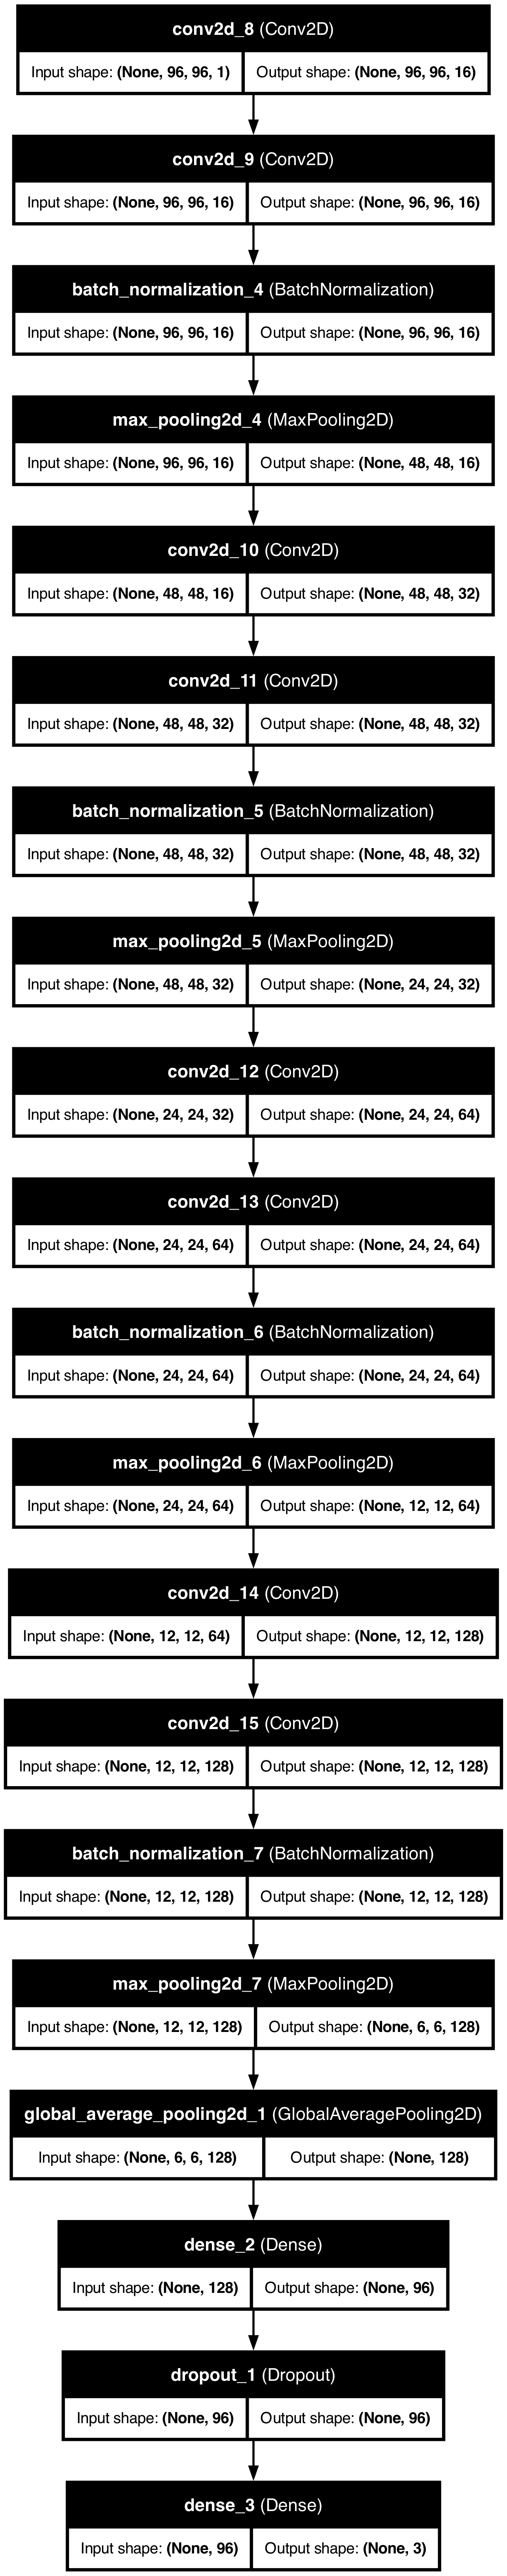

In [16]:
from tensorflow.keras.utils import plot_model
import pydot
import graphviz

model = CNN_2D()
plot_model(model.model, to_file='Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/model.png', show_shapes=True, show_layer_names=True)


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

 Trainable params: 306,387 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 333ms/step - accuracy: 0.9779 - loss: 0.0240 - val_accuracy: 0.9908 - val_loss: 0.0588
Epoch 17/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9997 - loss: 0.0027
Epoch 17: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 369ms/step - accuracy: 0.9997 - loss: 0.0027 - val_accuracy: 0.9908 - val_loss: 0.0703
Epoch 18/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 1.0000 - loss: 0.0015
Epoch 18: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 351ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9908 - val_loss: 0.0569
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9999 - loss: 0.0014
Epoch 19: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 28s 341ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 0.9662 - val_loss: 0.1621
Epoch 20/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 1.0000 - loss: 0.0015
Epoch 20: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 28s 345ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9923 - val_loss: 0.0383
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9996 - loss: 0.0011
Epoch 22: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 332ms/step - accuracy: 0.9996 - loss: 0.0011 - val_accuracy: 0.9923 - val_loss: 0.0340
Epoch 23/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 1.0000 - loss: 4.2992e-04
Epoch 23: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 28s 339ms/step - accuracy: 1.0000 - loss: 4.3118e-04 - val_accuracy: 0.9923 - val_loss: 0.0305
Epoch 24/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.9999 - loss: 0.0012
Epoch 24: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 351ms/step - accuracy: 0.9999 - loss: 0.0012 - val_accuracy: 0.9923 - val_loss: 0.0447
Epoch 25/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 1.0000 - loss: 5.9971e-04
Epoch 25

82/82 ━━━━━━━━━━━━━━━━━━━━ 28s 343ms/step - accuracy: 1.0000 - loss: 3.2393e-04 - val_accuracy: 0.9939 - val_loss: 0.0394
Epoch 27/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 1.0000 - loss: 3.4182e-04
Epoch 27: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 318ms/step - accuracy: 1.0000 - loss: 3.4181e-04 - val_accuracy: 0.9939 - val_loss: 0.0340
Epoch 28/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 1.0000 - loss: 4.2321e-04
Epoch 28: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 28s 346ms/step - accuracy: 1.0000 - loss: 4.2348e-04 - val_accuracy: 0.9939 - val_loss: 0.0358
Epoch 29/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 1.0000 - loss: 3.4902e-04
Epoch 29: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 358ms/step - accuracy: 1.0000 - loss: 3.5021e-04 - val_accuracy: 0.9923 - val_loss: 0.0353
Epoch 30/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 1.0000 - loss:

82/82 ━━━━━━━━━━━━━━━━━━━━ 36s 439ms/step - accuracy: 1.0000 - loss: 2.8288e-04 - val_accuracy: 0.9954 - val_loss: 0.0293
Epoch 32/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 1.0000 - loss: 3.7293e-04
Epoch 32: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 349ms/step - accuracy: 1.0000 - loss: 3.7115e-04 - val_accuracy: 0.9939 - val_loss: 0.0326
Epoch 33/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 1.0000 - loss: 3.6177e-04
Epoch 33: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 366ms/step - accuracy: 1.0000 - loss: 3.6026e-04 - val_accuracy: 0.9939 - val_loss: 0.0345
Epoch 34/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 1.0000 - loss: 1.1424e-04
Epoch 34: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 410ms/step - accuracy: 1.0000 - loss: 1.1439e-04 - val_accuracy: 0.9939 - val_loss: 0.0354
Epoch 35/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 1.0000 - loss:

82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 368ms/step - accuracy: 1.0000 - loss: 9.4756e-05 - val_accuracy: 0.9969 - val_loss: 0.0314
Epoch 46/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 1.0000 - loss: 5.4531e-05
Epoch 46: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 362ms/step - accuracy: 1.0000 - loss: 5.4781e-05 - val_accuracy: 0.9939 - val_loss: 0.0339
Epoch 47/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 1.0000 - loss: 6.7985e-05
Epoch 47: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 360ms/step - accuracy: 1.0000 - loss: 6.7898e-05 - val_accuracy: 0.9939 - val_loss: 0.0385
Epoch 48/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 1.0000 - loss: 4.3405e-05
Epoch 48: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 371ms/step - accuracy: 1.0000 - loss: 4.3413e-05 - val_accuracy: 0.9939 - val_loss: 0.0352
Epoch 49/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 1.0000 - loss:

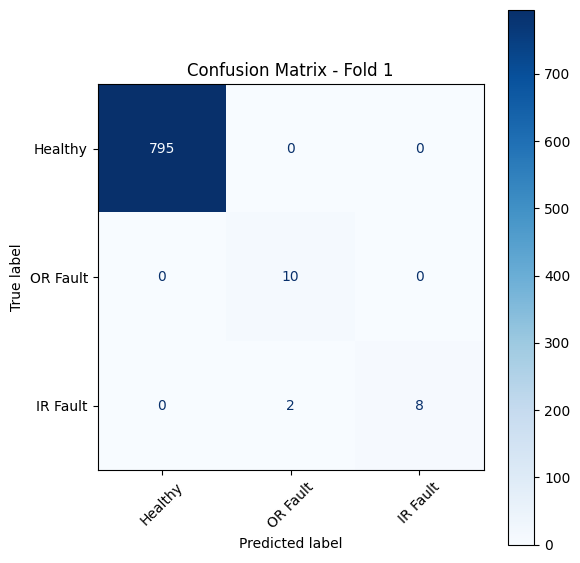

Saved confusion matrix for Fold 1 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/confusion_matrices/confusion_matrix_fold_1.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 38s 470ms/step - accuracy: 0.8839 - loss: 0.2709 - val_accuracy: 0.9831 - val_loss: 0.1120
Epoch 8/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.8393 - loss: 0.5243
Epoch 8: val_accuracy did not improve from 0.98310
82/82 ━━━━━━━━━━━━━━━━━━━━ 36s 436ms/step - accuracy: 0.8386 - loss: 0.5242 - val_accuracy: 0.8157 - val_loss: 0.4389
Epoch 9/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.8599 - loss: 0.3759
Epoch 9: val_accuracy did not improve from 0.98310
82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 371ms/step - accuracy: 0.8597 - loss: 0.3757 - val_accuracy: 0.8095 - val_loss: 0.4476
Epoch 10/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.8932 - loss: 0.2537
Epoch 10: val_accuracy did not improve from 0.98310
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 329ms/step - accuracy: 0.8930 - loss: 0.2547 - val_accuracy: 0.7435 - val_loss: 0.5321
Epoch 11/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.8953 - loss: 0.2118
Epoch 11: val_accuracy d

82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 353ms/step - accuracy: 0.9539 - loss: 0.0990 - val_accuracy: 0.9892 - val_loss: 0.0357
Epoch 13/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.9531 - loss: 0.0818
Epoch 13: val_accuracy improved from 0.98925 to 0.99386, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_2.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 318ms/step - accuracy: 0.9530 - loss: 0.0818 - val_accuracy: 0.9939 - val_loss: 0.0265
Epoch 14/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9797 - loss: 0.0392
Epoch 14: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 331ms/step - accuracy: 0.9795 - loss: 0.0396 - val_accuracy: 0.0845 - val_loss: 8.8586
Epoch 15/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.7820 - loss: 0.5598
Epoch 15: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 327ms/step - accuracy: 0.7819 - loss: 0.5586 - val_accuracy: 0.0230 - val_loss: 7.6711
Epoch 16/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8831 - loss: 0.1973
Epoch 16: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 328ms/step - accuracy: 0.8833 - loss: 0.1971 - val_accuracy: 0.9677 - val_loss: 0.1077
Epoch 17/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.9387 - loss: 0.1292
Epoch 17: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 320ms/step - accuracy: 0.9622 - loss: 0.0746 - val_accuracy: 0.9969 - val_loss: 0.0243
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.9828 - loss: 0.0346
Epoch 19: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 330ms/step - accuracy: 0.9828 - loss: 0.0346 - val_accuracy: 0.9831 - val_loss: 0.0525
Epoch 20/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9802 - loss: 0.0357
Epoch 20: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 313ms/step - accuracy: 0.9803 - loss: 0.0356 - val_accuracy: 0.9969 - val_loss: 0.0210
Epoch 21/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9901 - loss: 0.0218
Epoch 21: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 323ms/step - accuracy: 0.9901 - loss: 0.0219 - val_accuracy: 0.9908 - val_loss: 0.0381
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9847 - loss: 0.0181
Epoch 22: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 355ms/step - accuracy: 1.0000 - loss: 4.4438e-04 - val_accuracy: 0.9985 - val_loss: 0.0126
Epoch 46/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.9999 - loss: 5.3623e-04
Epoch 46: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 349ms/step - accuracy: 0.9999 - loss: 5.3572e-04 - val_accuracy: 0.9969 - val_loss: 0.0185
Epoch 47/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 1.0000 - loss: 2.1954e-04
Epoch 47: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 28s 343ms/step - accuracy: 1.0000 - loss: 2.1927e-04 - val_accuracy: 0.9969 - val_loss: 0.0182
Epoch 48/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 1.0000 - loss: 3.4725e-04
Epoch 48: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 358ms/step - accuracy: 1.0000 - loss: 3.4992e-04 - val_accuracy: 0.9969 - val_loss: 0.0152
Epoch 49/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 1.0000 - loss:

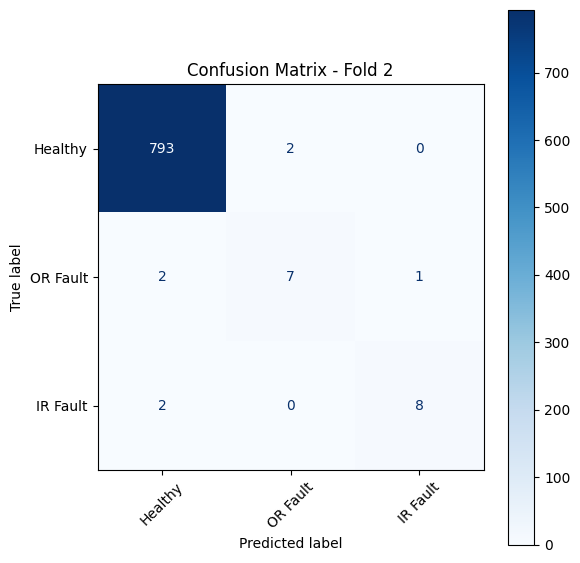

Saved confusion matrix for Fold 2 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/confusion_matrices/confusion_matrix_fold_2.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 330ms/step - accuracy: 0.8931 - loss: 0.2699 - val_accuracy: 0.9862 - val_loss: 0.0498
Epoch 16/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9618 - loss: 0.0732
Epoch 16: val_accuracy improved from 0.98618 to 0.98771, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_3.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 319ms/step - accuracy: 0.9617 - loss: 0.0732 - val_accuracy: 0.9877 - val_loss: 0.0570
Epoch 17/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9842 - loss: 0.0302
Epoch 17: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 324ms/step - accuracy: 0.9841 - loss: 0.0303 - val_accuracy: 0.9616 - val_loss: 0.0902
Epoch 18/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.9848 - loss: 0.0233
Epoch 18: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 324ms/step - accuracy: 0.9848 - loss: 0.0234 - val_accuracy: 0.9570 - val_loss: 0.1432
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9776 - loss: 0.0316
Epoch 19: val_accuracy improved from 0.98771 to 0.99232, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_3.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 317ms/step - accuracy: 0.9776 - loss: 0.0316 - val_accuracy: 0.9923 - val_loss: 0.0186
Epoch 20/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.9932 - loss: 0.0174
Epoch 20: val_accuracy improved from 0.99232 to 0.99539, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_3.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 391ms/step - accuracy: 0.9932 - loss: 0.0173 - val_accuracy: 0.9954 - val_loss: 0.0233
Epoch 21/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.9966 - loss: 0.0078
Epoch 21: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 347ms/step - accuracy: 0.9966 - loss: 0.0078 - val_accuracy: 0.9939 - val_loss: 0.0178
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9995 - loss: 0.0028
Epoch 22: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 323ms/step - accuracy: 0.9995 - loss: 0.0028 - val_accuracy: 0.9939 - val_loss: 0.0218
Epoch 23/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 1.0000 - loss: 0.0022
Epoch 23: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 33s 403ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.9954 - val_loss: 0.0173
Epoch 24/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.9993 - loss: 0.0030
Epoch 24: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 321ms/step - accuracy: 1.0000 - loss: 2.0245e-04 - val_accuracy: 0.9969 - val_loss: 0.0106
Epoch 52/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 1.0000 - loss: 2.9415e-04
Epoch 52: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 332ms/step - accuracy: 1.0000 - loss: 3.0442e-04 - val_accuracy: 0.9862 - val_loss: 0.0528
Epoch 53/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 1.0000 - loss: 1.9739e-04
Epoch 53: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 321ms/step - accuracy: 1.0000 - loss: 1.9819e-04 - val_accuracy: 0.9939 - val_loss: 0.0275
Epoch 54/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 1.0000 - loss: 2.4114e-04
Epoch 54: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 320ms/step - accuracy: 1.0000 - loss: 2.4222e-04 - val_accuracy: 0.9939 - val_loss: 0.0191
Epoch 55/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 1.0000 - loss:

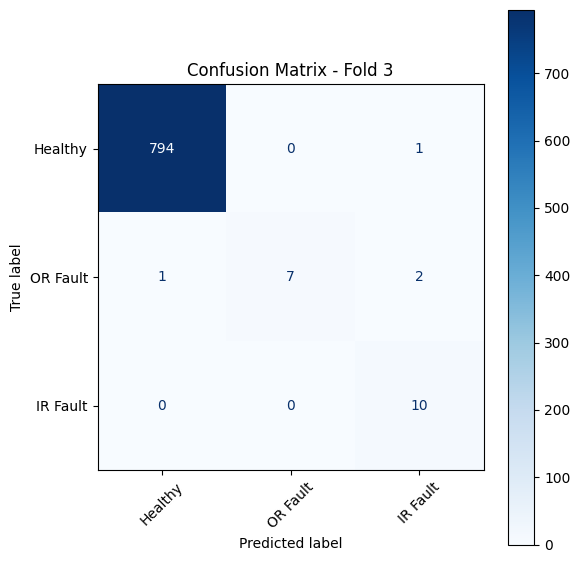

Saved confusion matrix for Fold 3 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/confusion_matrices/confusion_matrix_fold_3.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 321ms/step - accuracy: 0.9742 - loss: 0.0325 - val_accuracy: 0.9892 - val_loss: 0.0287
Epoch 16/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9949 - loss: 0.0122
Epoch 16: val_accuracy improved from 0.98925 to 0.99386, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 320ms/step - accuracy: 0.9949 - loss: 0.0122 - val_accuracy: 0.9939 - val_loss: 0.0235
Epoch 17/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.9979 - loss: 0.0068
Epoch 17: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 333ms/step - accuracy: 0.9979 - loss: 0.0068 - val_accuracy: 0.9939 - val_loss: 0.0214
Epoch 18/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9983 - loss: 0.0088
Epoch 18: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 414ms/step - accuracy: 0.9983 - loss: 0.0087 - val_accuracy: 0.9923 - val_loss: 0.0254
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9997 - loss: 0.0031
Epoch 19: val_accuracy improved from 0.99386 to 0.99539, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 363ms/step - accuracy: 0.9997 - loss: 0.0031 - val_accuracy: 0.9954 - val_loss: 0.0142
Epoch 20/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9999 - loss: 0.0053
Epoch 20: val_accuracy improved from 0.99539 to 0.99693, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 320ms/step - accuracy: 0.9999 - loss: 0.0053 - val_accuracy: 0.9969 - val_loss: 0.0127
Epoch 21/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 1.0000 - loss: 0.0018
Epoch 21: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 318ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9954 - val_loss: 0.0161
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 1.0000 - loss: 0.0024
Epoch 22: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 323ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9969 - val_loss: 0.0135
Epoch 23/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 1.0000 - loss: 0.0017
Epoch 23: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 326ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9969 - val_loss: 0.0109
Epoch 24/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 1.0000 - loss: 7.6607e-04
Epoch 24: val_ac

82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 309ms/step - accuracy: 1.0000 - loss: 3.7806e-04 - val_accuracy: 0.9985 - val_loss: 0.0095
Epoch 37/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 1.0000 - loss: 6.5233e-04
Epoch 37: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 311ms/step - accuracy: 1.0000 - loss: 6.5014e-04 - val_accuracy: 0.9969 - val_loss: 0.0091
Epoch 38/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 1.0000 - loss: 1.7874e-04
Epoch 38: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 316ms/step - accuracy: 1.0000 - loss: 1.7861e-04 - val_accuracy: 0.9954 - val_loss: 0.0165
Epoch 39/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 1.0000 - loss: 3.0538e-04
Epoch 39: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 326ms/step - accuracy: 1.0000 - loss: 3.0464e-04 - val_accuracy: 0.9954 - val_loss: 0.0122
Epoch 40/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 1.0000 - loss:

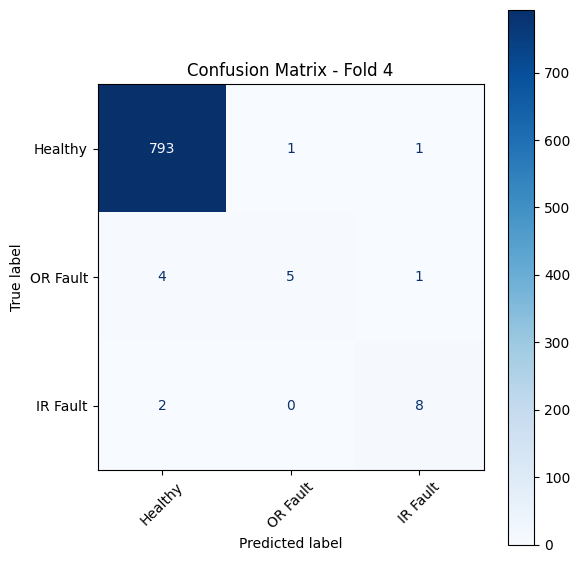

Saved confusion matrix for Fold 4 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/confusion_matrices/confusion_matrix_fold_4.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 334ms/step - accuracy: 0.9627 - loss: 0.0758 - val_accuracy: 0.9892 - val_loss: 0.0393
Epoch 15/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9810 - loss: 0.0453
Epoch 15: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 320ms/step - accuracy: 0.9811 - loss: 0.0453 - val_accuracy: 0.9862 - val_loss: 0.0604
Epoch 16/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9874 - loss: 0.0222
Epoch 16: val_accuracy improved from 0.98925 to 0.99232, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 315ms/step - accuracy: 0.9874 - loss: 0.0222 - val_accuracy: 0.9923 - val_loss: 0.0243
Epoch 17/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9730 - loss: 0.0293
Epoch 17: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 318ms/step - accuracy: 0.9731 - loss: 0.0292 - val_accuracy: 0.9923 - val_loss: 0.0163
Epoch 18/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9955 - loss: 0.0086
Epoch 18: val_accuracy improved from 0.99232 to 0.99539, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 326ms/step - accuracy: 0.9955 - loss: 0.0086 - val_accuracy: 0.9954 - val_loss: 0.0155
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.9991 - loss: 0.0071
Epoch 19: val_accuracy improved from 0.99539 to 0.99693, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 248ms/step - accuracy: 0.9991 - loss: 0.0071 - val_accuracy: 0.9969 - val_loss: 0.0125
Epoch 20/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9985 - loss: 0.0040
Epoch 20: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.9985 - loss: 0.0040 - val_accuracy: 0.9969 - val_loss: 0.0121
Epoch 21/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - loss: 0.0022
Epoch 21: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.9969 - val_loss: 0.0126
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9998 - loss: 0.0046
Epoch 22: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 191ms/step - accuracy: 0.9998 - loss: 0.0046 - val_accuracy: 0.9939 - val_loss: 0.0136
Epoch 23/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 1.0000 - loss: 0.0025
Epoch 23: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 314ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 0.9985 - val_loss: 0.0073
Epoch 26/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 1.0000 - loss: 0.0017
Epoch 26: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 319ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9985 - val_loss: 0.0089
Epoch 27/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 1.0000 - loss: 0.0014
Epoch 27: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 322ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9985 - val_loss: 0.0061
Epoch 28/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 1.0000 - loss: 0.0020 
Epoch 29: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 1037s 13s/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9969 - val_loss: 0.0075
Epoch 30/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 1.0000 - loss: 7.8836e-04
Epoch 30: val_acc

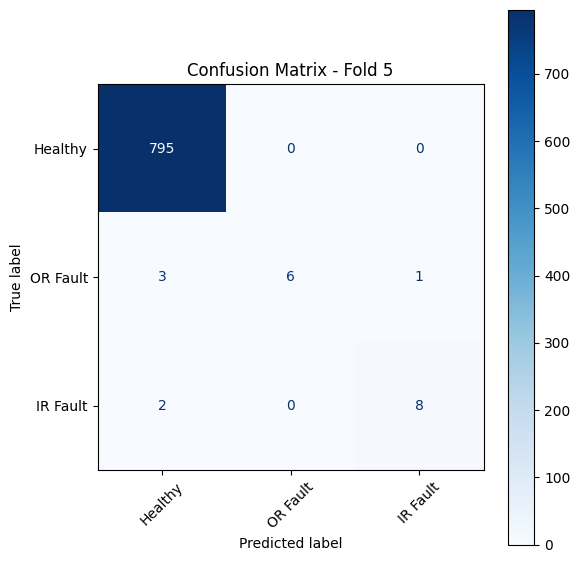

Saved confusion matrix for Fold 5 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/confusion_matrices/confusion_matrix_fold_5.png
Total Computation Time: 20509.19 seconds (341.82 minutes)


In [12]:
# Training with k-fold validation
kSplits = 5
accuracy_2D = []
precision_2D = []
recall_2D = []
f1_2D = []
log_loss_2D = []
balanced_accuracy_2D = []
precision_2D_macro = []
recall_2D_macro = []
f1_2D_macro = []
accuracy_2D_test = []
precision_2D_test = []
recall_2D_test = []
log_loss_2D_test = []
f1_2D_test = []
precision_2D_test_macro = []
recall_2D_test_macro = []
f1_2D_test_macro = []
balanced_accuracy_2D_test = []
# accuracy_val = []

foldername = "Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/"

condition_map = {
    0: "Healthy",
    1: "OR Fault",
    2: "IR Fault"
}

early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
start_time = time.time()
y_labels = np.argmax(y_train_positional_split, axis=1)

kfold = StratifiedKFold(n_splits=kSplits, random_state=32, shuffle=True)

for fold, (train_idx, test_idx) in enumerate(kfold.split(X_2D_train, y_labels)):

    Classification_2D = CNN_2D()

    checkpoint_filepath = os.path.join(foldername, f"best_model_fold_{fold+1}.h5")
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )

    Classification_2D.model.fit(X_2D_train[train_idx], y_train_positional_split[train_idx],
                                validation_data=(X_2D_train[test_idx], y_train_positional_split[test_idx]),
                                epochs=200, callbacks=[early_stopping, checkpoint], verbose=1,class_weight=class_weights)

    print(f"Best model for Fold {fold+1} saved to: {checkpoint_filepath}")

    # Train set metrics
    y_pred_proba_train = Classification_2D.model.predict(X_2D_train)
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(y_train_positional_split, axis=1)

    accuracy_2D.append(accuracy_score(y_true_train, y_pred_train))
    precision_2D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_2D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_2D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_2D.append(log_loss(y_true_train, y_pred_proba_train))
    balanced_accuracy_2D.append(balanced_accuracy_score(y_true_train, y_pred_train))
    precision_2D_macro.append(precision_score(y_true_train, y_pred_train, average='macro'))
    recall_2D_macro.append(recall_score(y_true_train, y_pred_train, average='macro'))
    f1_2D_macro.append(f1_score(y_true_train, y_pred_train, average='macro'))

    # Test set metrics
    y_pred_proba_test = Classification_2D.model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(y_test_positional_split, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[condition_map[i] for i in range(3)])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.grid(False)
    plt.tight_layout()

    # Save confusion matrix
    save_dir = os.path.join(foldername, "confusion_matrices")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"confusion_matrix_fold_{fold + 1}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved confusion matrix for Fold {fold + 1} at: {save_path}")

    # accuracy_val.append(accuracy_score(X_2D_train[test_idx], y_train_positional_split[test_idx]))
    accuracy_2D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_2D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_2D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_2D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    precision_2D_test_macro.append(precision_score(y_true_test, y_pred_test, average='macro'))
    recall_2D_test_macro.append(recall_score(y_true_test, y_pred_test, average='macro'))
    f1_2D_test_macro.append(f1_score(y_true_test, y_pred_test, average='macro'))
    log_loss_2D_test.append(log_loss(y_true_test, y_pred_proba_test))
    balanced_accuracy_2D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total Computation Time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")


In [13]:
# Aggregated metrics
CNN_2D_train_accuracy = np.mean(accuracy_2D) * 100
CNN_2D_test_accuracy = np.mean(accuracy_2D_test) * 100
CNN_2D_train_precision = np.mean(precision_2D) * 100
CNN_2D_test_precision = np.mean(precision_2D_test) * 100
CNN_2D_train_recall = np.mean(recall_2D) * 100
CNN_2D_test_recall = np.mean(recall_2D_test) * 100
CNN_2D_train_f1 = np.mean(f1_2D) * 100
CNN_2D_test_f1 = np.mean(f1_2D_test) * 100
CNN_2D_train_precision_macro = np.mean(precision_2D_macro) * 100
CNN_2D_train_recall_macro = np.mean(recall_2D_macro) * 100
CNN_2D_train_f1_macro = np.mean(f1_2D_macro) * 100
CNN_2D_test_precision_macro = np.mean(precision_2D_test_macro) * 100
CNN_2D_test_recall_macro = np.mean(recall_2D_test_macro) * 100
CNN_2D_test_f1_macro = np.mean(f1_2D_test_macro) * 100
CNN_2D_train_log_loss = np.mean(log_loss_2D)
CNN_2D_test_log_loss = np.mean(log_loss_2D_test)
CNN_2D_train_balanced_accuracy = np.mean(balanced_accuracy_2D) * 100
CNN_2D_test_balanced_accuracy = np.mean(balanced_accuracy_2D_test) * 100
# CNN_2D_val_accuracy = np.mean(accuracy_val) * 100

# Print metrics
print(f"Train Accuracy: {CNN_2D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_2D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_2D_train_precision:.2f}%")
print(f"Test Precision: {CNN_2D_test_precision:.2f}%")
print(f"Train Recall: {CNN_2D_train_recall:.2f}%")
print(f"Test Recall: {CNN_2D_test_recall:.2f}%")
print(f"Train F1: {CNN_2D_train_f1:.2f}%")
print(f"Test F1: {CNN_2D_test_f1:.2f}%")
print(f"Train Log Loss: {CNN_2D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_2D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_2D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_2D_test_balanced_accuracy:.2f}%")

print(f"Train Precision (Macro): {CNN_2D_train_precision_macro:.2f}%")
print(f"Train Recall (Macro): {CNN_2D_train_recall_macro:.2f}%")
print(f"Train F1 Score (Macro): {CNN_2D_train_f1_macro:.2f}%")

print(f"Test Precision (Macro): {CNN_2D_test_precision_macro:.2f}%")
print(f"Test Recall (Macro): {CNN_2D_test_recall_macro:.2f}%")
print(f"Test F1 Score (Macro): {CNN_2D_test_f1_macro:.2f}%")

# print(f"CNN_2D_val_accuracy: {CNN_2D_val_accuracy:.2f}%")


Train Accuracy: 99.95%
Test Accuracy: 99.31%
Train Precision: 99.95%
Test Precision: 99.31%
Train Recall: 99.95%
Test Recall: 99.31%
Train F1: 99.95%
Test F1: 99.27%
Train Log Loss: 0.0035
Test Log Loss: 0.0295
Train Balanced Accuracy: 98.83%
Test Balanced Accuracy: 84.62%
Train Precision (Macro): 99.81%
Train Recall (Macro): 98.83%
Train F1 Score (Macro): 99.32%
Test Precision (Macro): 91.81%
Test Recall (Macro): 84.62%
Test F1 Score (Macro): 87.16%


102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step


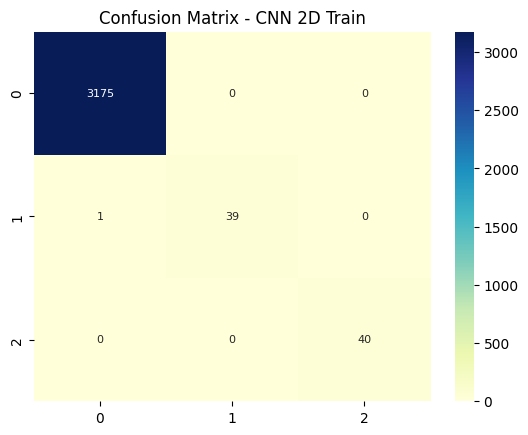

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step


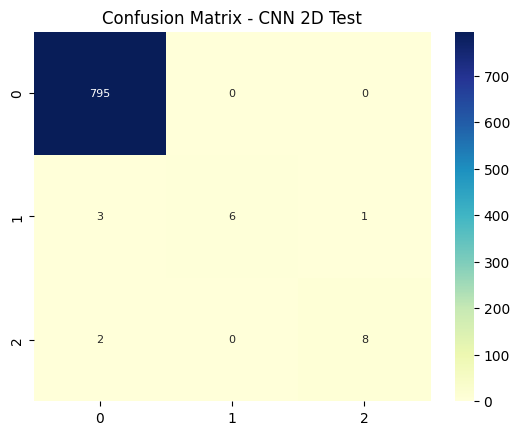

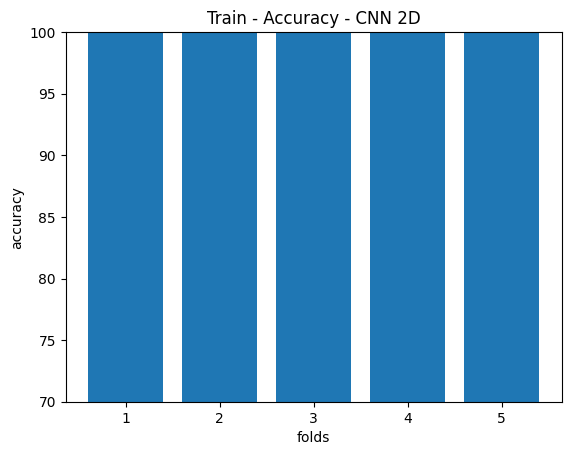

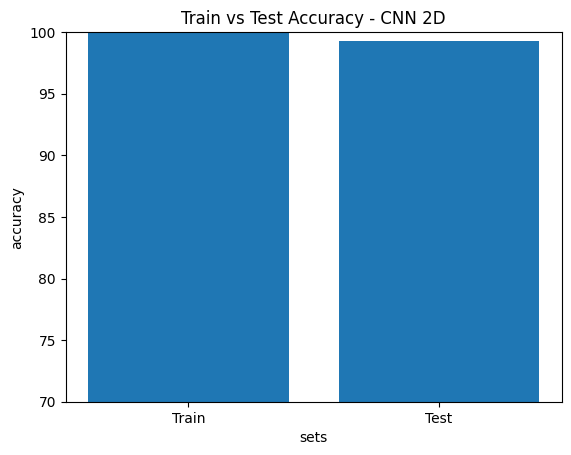

In [14]:
# Confusion Matrix Calculation
def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.model.predict(X)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y, axis=1)
    return confusion_matrix(y_true, y_pred)

# Plot results - CNN 2D
plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_train, y_train_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_test, y_test_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_2D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 2D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()


In [18]:




# Create DataFrame from per-fold metrics
metrics_df = pd.DataFrame({
    'Fold': np.arange(1, 5 + 1),
    
    'Train Accuracy (%)': np.array(accuracy_2D) * 100,
    'Test Accuracy (%)': np.array(accuracy_2D_test) * 100,

    'Train Precision (%)': np.array(precision_2D) * 100,
    'Test Precision (%)': np.array(precision_2D_test) * 100,

    'Train Recall (%)': np.array(recall_2D) * 100,
    'Test Recall (%)': np.array(recall_2D_test) * 100,

    'Train F1-score (%)': np.array(f1_2D) * 100,
    'Test F1-score (%)': np.array(f1_2D_test) * 100,

    'Train Precision-Macro (%)': np.array(precision_2D_macro) * 100,
    'Test Precision-Macro (%)': np.array(precision_2D_test_macro) * 100,

    'Train Recall-Macro (%)': np.array(recall_2D_macro) * 100,
    'Test Recall-Macro (%)': np.array(recall_2D_test_macro) * 100,

    'Train F1-score (%)': np.array(f1_2D_macro) * 100,
    'Test F1-score (%)': np.array(f1_2D_test_macro) * 100,

    'Train Log Loss': log_loss_2D,
    'Test Log Loss': log_loss_2D_test,

    'Train Balanced Accuracy (%)': np.array(balanced_accuracy_2D) * 100,
    'Test Balanced Accuracy (%)': np.array(balanced_accuracy_2D_test) * 100,
})

metrics_df.round(2)
# Sort by highest Test F1-score (%)
# sorted_df = metrics_df.sort_values(by='Test Balanced Accuracy (%)', ascending=False)
# sorted_df.round(2)

NameError: name 'accuracy_2D' is not defined

In [20]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, log_loss
)

# Set paths
foldername = "Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS"
num_folds = 5  # Assuming models are: best_model_fold_1.h5 to _5.h5

# Use these test variables from your data pipeline
# Already loaded:
# X_test_split, y_test_positional_split

# Flatten labels
y_true = np.argmax(y_test_positional_split, axis=1)

# Containers
folds = []
accuracy_test = []
precision_test = []
recall_test = []
f1_test = []
precision_macro = []
recall_macro = []
f1_macro = []
log_loss_test = []
balanced_acc = []

# Loop through models
for fold in range(1, num_folds + 1):
    model_path = os.path.join(foldername, f"best_model_fold_{fold}.h5")
    print(f"\nEvaluating model: {model_path}")

    model = load_model(model_path)
    y_pred_proba = model.predict(X_test_split, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    folds.append(fold)
    accuracy_test.append(accuracy_score(y_true, y_pred) * 100)
    precision_test.append(precision_score(y_true, y_pred, average='weighted') * 100)
    recall_test.append(recall_score(y_true, y_pred, average='weighted') * 100)
    f1_test.append(f1_score(y_true, y_pred, average='weighted') * 100)

    precision_macro.append(precision_score(y_true, y_pred, average='macro') * 100)
    recall_macro.append(recall_score(y_true, y_pred, average='macro') * 100)
    f1_macro.append(f1_score(y_true, y_pred, average='macro') * 100)

    log_loss_test.append(log_loss(y_true, y_pred_proba))
    balanced_acc.append(balanced_accuracy_score(y_true, y_pred) * 100)

# Create and print metrics DataFrame
metrics_df = pd.DataFrame({
    'Fold': folds,
    'Test Accuracy (%)': accuracy_test,
    'Test Precision (%)': precision_test,
    'Test Recall (%)': recall_test,
    'Test F1-score (%)': f1_test,
    'Test Precision (Macro) (%)': precision_macro,
    'Test Recall (Macro) (%)': recall_macro,
    'Test F1-score (Macro) (%)': f1_macro,
    'Test Log Loss': log_loss_test,
    'Test Balanced Accuracy (%)': balanced_acc,
}).round(2)

print("\n Test Metrics Summary (Same Test Set Across All Models):")
metrics_df



Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_1.h5



Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_2.h5



Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_3.h5



Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_4.h5



Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS/best_model_fold_5.h5



 Test Metrics Summary (Same Test Set Across All Models):


,Fold,Test Accuracy (%),Test Precision (%),Test Recall (%),Test F1-score (%),Test Precision (Macro) (%),Test Recall (Macro) (%),Test F1-score (Macro) (%),Test Log Loss,Test Balanced Accuracy (%)
0,1,99.75,99.80,99.75,99.75,94.44,93.33,93.27,0.01,93.33
1,2,99.14,99.10,99.14,99.12,88.72,83.25,85.84,0.03,83.25
2,3,99.51,99.59,99.51,99.50,92.27,89.96,89.73,0.04,89.96
3,4,98.90,98.82,98.90,98.80,87.53,76.58,80.67,0.04,76.58
4,5,99.26,99.25,99.26,99.19,96.09,80.00,86.30,0.02,80.00
